# Testing Libraries

In [1]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=1
!export BART_CPU_ONLY=1
!export CUDA_LAUNCH_BLOCKING=1

import importlib
import sys
import os

os.environ['BART_TOOLBOX_PATH'] = '/home/rinbha/Packages/bart-0.9.00'
os.environ['BART_CPU_ONLY'] = '1'
sys.path.append(os.path.join(os.environ['BART_TOOLBOX_PATH'], 'python'))

sys.path.insert(0, "/home/rinbha/Research/BPT_MOTUS/nonrigid-motion-bpt")
sys.path.insert(0, "/home/rinbha/Research/BPT_MOTUS/bpt_mrmotus_2025/bpt_mrmotus_2025/mrmotus_custom_packages/sigpy-custom")
sys.path.insert(0, "/home/rinbha/Research/BPT_MOTUS/bpt_mrmotus_2025/bpt_mrmotus_2025/mrmotus_custom_packages/torch-interpol")
import sigpy as sp
import sigpy.mri as mr
import sigpy.plot as pl

import matplotlib.pyplot as plt
import numpy as np

# plotting
%matplotlib widget
plt.rcParams.update({
    'axes.spines.top': False,           # Remove top spine
    'axes.spines.right': False,         # Remove right spine
    'axes.titlesize': 20,               # Increase title font size
    'axes.labelsize': 18,               # Increase axis label font size
    'xtick.labelsize': 16,              # Increase x-tick label size
    'ytick.labelsize': 16,              # Increase y-tick label size
    "text.usetex": False,                # Enable LaTeX 
    'legend.fontsize': 12,
    'font.family': 'Avenir' # Avenir font
})

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=1


ModuleNotFoundError: No module named 'numpy'

In [4]:
import os
my_secret_variable = "The server is alive"
print(f"Current Process ID: {os.getpid()}")

Current Process ID: 1584951


## io

### Radial

In [18]:
# add paths
from bpt_motus.io import RadialArchive

In [19]:
import bpt_motus.io.radial_reader as rr
importlib.reload(rr)

from bpt_motus.io.radial_reader import RadialArchive

In [14]:
radial.metadata_dict

NameError: name 'radial' is not defined

In [ ]:
# Path to radial ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/hires_ute"
# Create the object
radial = RadialArchive(inpdir)

radial.get_ksp(force_reload=False)

INFO: Cached data not found... Extracting k-space.
INFO: Running command: /mikQNAP/sanand/UTE/pcvipr_recon_binary -export_kdata -hdf5 -f /mikLKS/rinbha/BPT/MRMOTUS/lung_ute/phantom_ute_121725/Series7/ScanArchive_UCB3TMR_20251217_174915420.h5 -dont_use_ge_channel_weights
ERROR: Error during pcvipr execution: Command '['/mikQNAP/sanand/UTE/pcvipr_recon_binary', '-export_kdata', '-hdf5', '-f', '/mikLKS/rinbha/BPT/MRMOTUS/lung_ute/phantom_ute_121725/Series7/ScanArchive_UCB3TMR_20251217_174915420.h5', '-dont_use_ge_channel_weights']' returned non-zero exit status 1.
INFO: Cached metadata not found / used — extracting.


KeyError: 'nr'

In [ ]:
print(f"xk shape: {radial.xk_time.shape}")
print(f"coords shape: {radial.coords_time.shape}")
print(f"dcf shape: {radial.dcf_time.shape}")
print(f"time_ordering shape: {radial.time_ordering.shape}")

xk shape: (22, 39950, 1633)
coords shape: (39950, 1633, 3)
dcf shape: (39950, 1633)
time_ordering shape: (39950,)


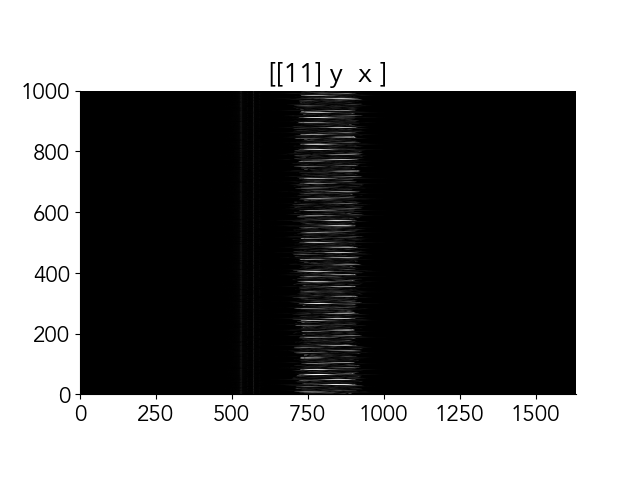

In [ ]:
xk_f = sp.ifft(radial.xk_time[:,:1000], axes=(-1,))
pl.ImagePlot(xk_f)

In [ ]:
del radial

### Bravo

In [ ]:
from bpt_motus.io import BravoArchive

In [ ]:
import bpt_motus.io.bravo_reader as br
importlib.reload(br)

from bpt_motus.io.bravo_reader import BravoArchive

In [15]:
# Path to BRAVO ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bravo/raw_data"

# Create the object
bravo = BravoArchive(inpdir)

bravo.get_ksp(force_reload=False)

INFO: Cached data not found / used — extracting k-space.
INFO: Cached metadata not found / used — extracting.
INFO: No embedded or cached kacq found — estimating from control packets.


In [17]:
print(f"xk_time shape: {bravo.xk_time.shape}")
print(f"xk_recon shape: {bravo.xk_recon.shape}")
print(f"coords shape: {bravo.coords.shape}")

xk_time shape: (22, 58520, 384)
xk_recon shape: (22, 384, 308, 190)
coords shape: (58520, 384, 3)


In [18]:
im_recon = sp.ifft(bravo.xk_recon, axes=(-1,-2,-3))

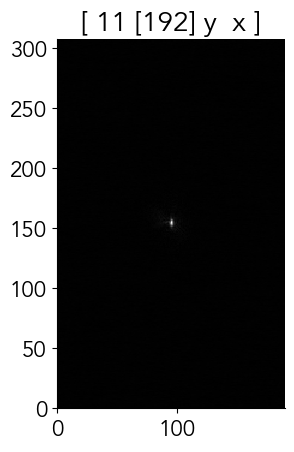

In [26]:
pl.ImagePlot(bravo.xk_recon)

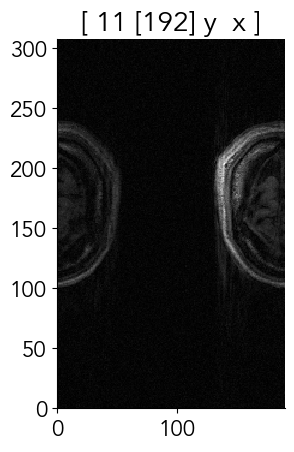

In [27]:
pl.ImagePlot(im_recon)

In [29]:
del bravo, im_recon

### Organize Radial Acquisitions into Phases

In [ ]:
from bpt_motus.io import SplitRadialAcq

In [ ]:
import bpt_motus.io.acq_splitter as acs
importlib.reload(acs)

from bpt_motus.io.acq_splitter import SplitRadialAcq

In [ ]:
# Path to radial ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/"
calib_source="hires"
no_motion_range=(0,15000)
calib_range=(20000,35000)
inf_range=(35000, None)
# Create the object
split_exp = SplitRadialAcq(inp_dir=inpdir, verbose=True, calib_source=calib_source, no_motion_range=no_motion_range, calib_range=calib_range, inf_range=inf_range)

In [ ]:
split_exp.run(force_reload=False)

INFO: Found split datasets. No need to split again.


## preprocessing

### Split k-space and BPT

In [ ]:
from bpt_motus.preprocessing import SplitXkBPT

In [ ]:
import bpt_motus.preprocessing.split_xk_bpt as sxb
importlib.reload(sxb)

from bpt_motus.preprocessing.split_xk_bpt import SplitXkBPT

In [ ]:
# Split no motion data
nomotion_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/no_motion"
split_xk_bpt_nm = SplitXkBPT(inp_dir=nomotion_inpdir, verbose=True)
split_xk_bpt_nm.run()
# Split calibration data
calib_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib"
split_xk_bpt_c = SplitXkBPT(inp_dir=calib_inpdir, verbose=True)
split_xk_bpt_c.run()
# Split inference data
inf_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/inf"
split_xk_bpt_inf = SplitXkBPT(inp_dir=inf_inpdir, verbose=True)
split_xk_bpt_inf.run()

INFO: Cleaned k-space and raw BPT/PT signals found. Opening...
INFO: Cleaned k-space and raw BPT/PT signals found. Opening...
INFO: Cleaned k-space and raw BPT/PT signals found. Opening...


In [ ]:
print(f"Cleaned k-space shape: {split_xk_bpt_nm.xk_cleaned.shape}")
print(f"BPT/PTs shape: {split_xk_bpt_nm.bpts.shape}")

Cleaned k-space shape: (6, 15000, 1633)
BPT/PTs shape: (4, 15000, 22)


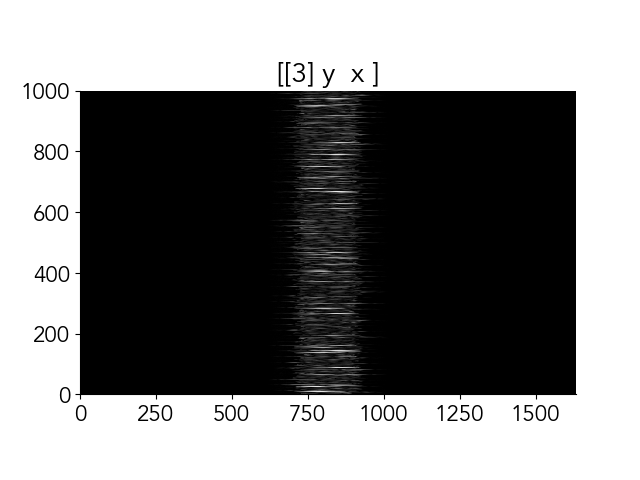

In [ ]:
xk_f = sp.ifft(split_xk_bpt_nm.xk_cleaned[:,:1000], axes=(-1,))
pl.ImagePlot(xk_f)

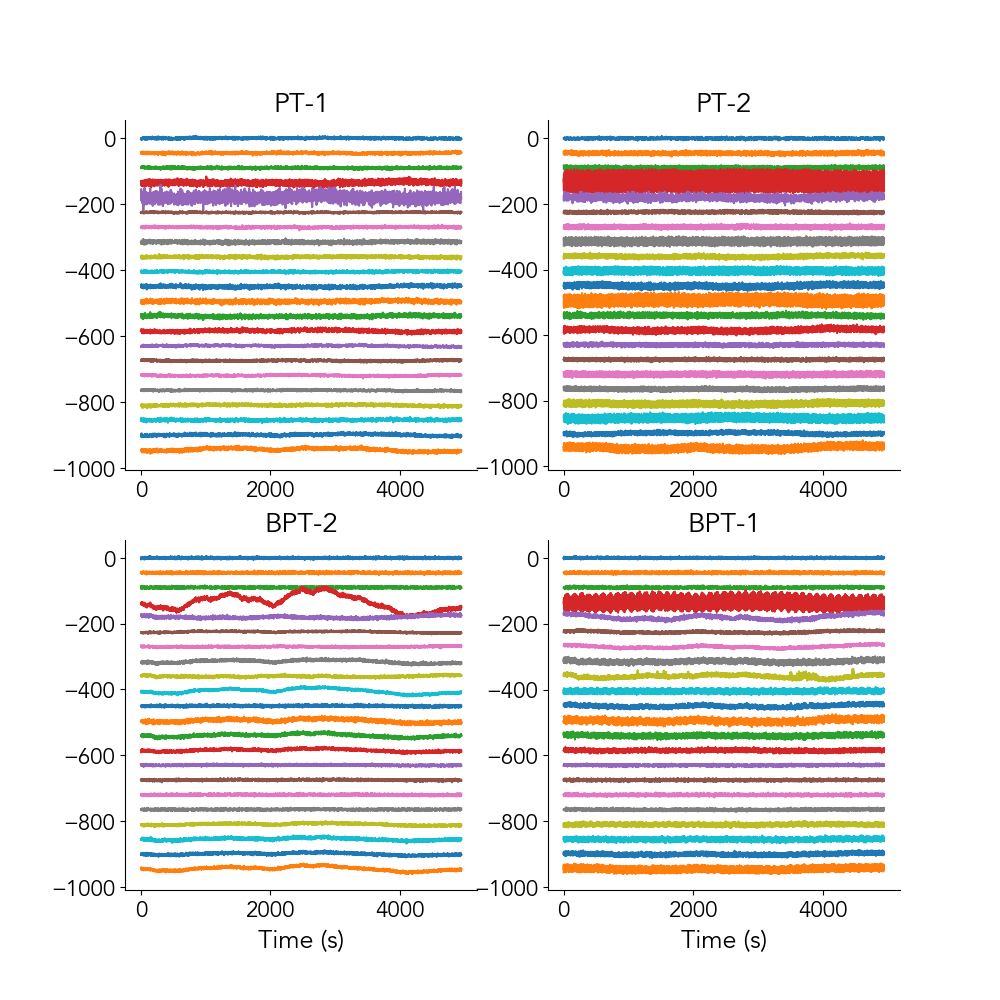

In [ ]:
def plot_bpt(bpt, tr=1, window=1, shift=0, figsize=(10,10), titles = ["PT-1", "PT-2", "BPT-2", "BPT-1"]):
    nbpts, npe, ncoils = bpt.shape
    
    plt.figure(figsize=figsize)
    t = np.arange(npe)*tr
    # Plot
    for i in range(nbpts):
        plt.subplot(nbpts//2, 2, i+1)
        plt.plot(t, bpt[i] - np.mean(bpt[i],axis=0) + np.arange(ncoils)*shift);
        plt.title(titles[i])
        if i > 1:
            plt.xlabel("Time (s)")

plot_bpt(split_xk_bpt_inf.bpts, shift = -45)

### Process BPT/PTs

In [ ]:
from bpt_motus.preprocessing import ProcessBPT

In [ ]:
import bpt_motus.preprocessing.process_bpt as pbpt
importlib.reload(pbpt)

from bpt_motus.preprocessing.process_bpt import ProcessBPT

In [ ]:
# Process calibration BPT
calib_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib"
proc_bpt_c = ProcessBPT(inp_dir=calib_inpdir, verbose=True, phase="calib")
proc_bpt_c.run()
# Process inference BPT
inf_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/inf"
proc_bpt_i = ProcessBPT(inp_dir=inf_inpdir, verbose=True, phase="inf")
proc_bpt_i.run()

INFO: Processed BPT/PTs found. Opening them...
INFO: Processed BPT/PTs found. Opening them...


In [ ]:
print(f"Processed BPT shape (calib): {proc_bpt_c.bpts_proc.shape}")
print(f"Processed BPT shape (inf): {proc_bpt_i.bpts_proc.shape}")

Processed BPT shape (calib): (15000, 16)
Processed BPT shape (inf): (4950, 16)


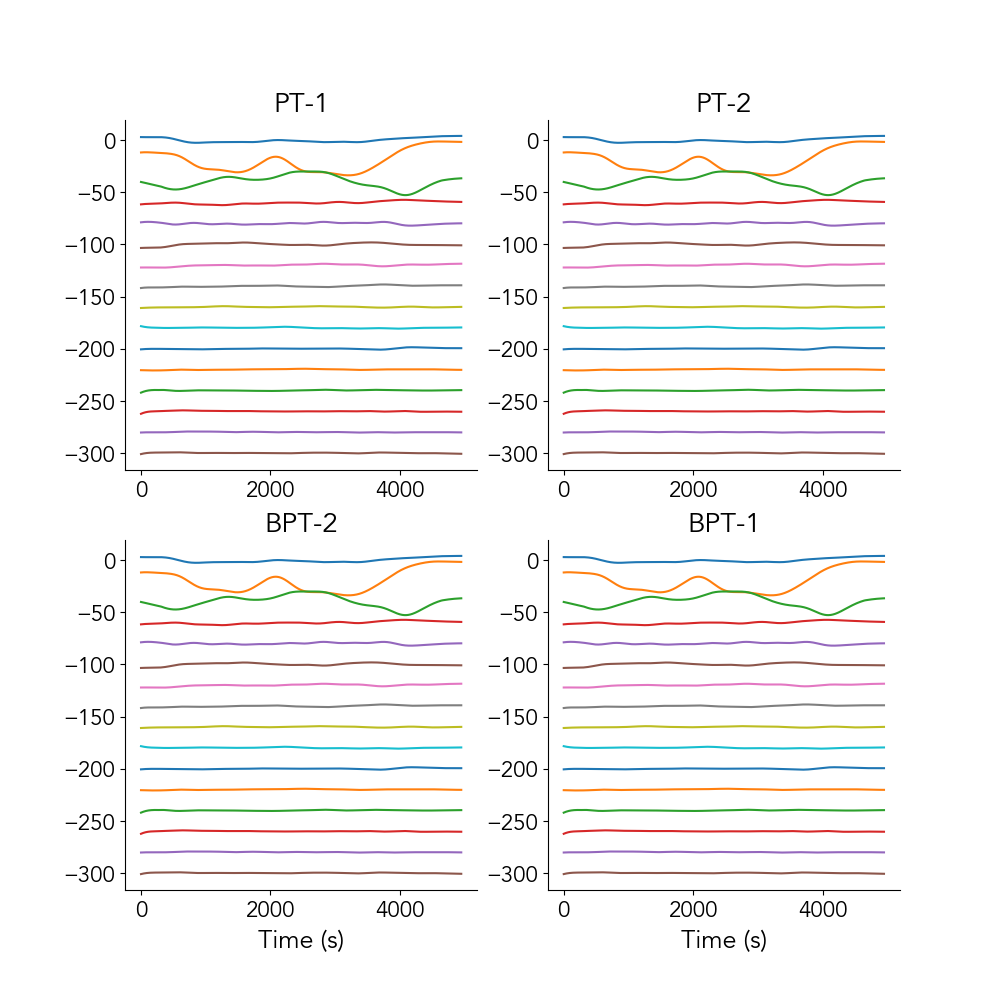

In [ ]:
plot_bpt(np.tile(proc_bpt_i.bpts_proc, (4,1,1)), shift = -20)

### Process xk

#### No Motion Reference

In [ ]:
from bpt_motus.preprocessing import NoMotionReference

In [ ]:
import bpt_motus.preprocessing.process_xk as px
importlib.reload(px)

from bpt_motus.preprocessing.process_xk import NoMotionReference

In [ ]:
# Path to no motion folder
nomotion_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/no_motion"

# Create the object
no_motion_reference = NoMotionReference(inp_dir=nomotion_inpdir, verbose=True)

In [ ]:
no_motion_reference.run(force_reload=False)

INFO: Reference image and CSMs found. Opening...


In [ ]:
S_old = np.load("/mikLKS/rinbha/BPT/MRMOTUS/results/bpt_volunteer_110924_2_results/Hires_No_Motion/Crop_3/S_nomotion_hires.npy")
csm_old = np.load("/mikLKS/rinbha/BPT/MRMOTUS/results/bpt_volunteer_110924_2_results/Hires_No_Motion/Crop_3/csm_hires.npy")

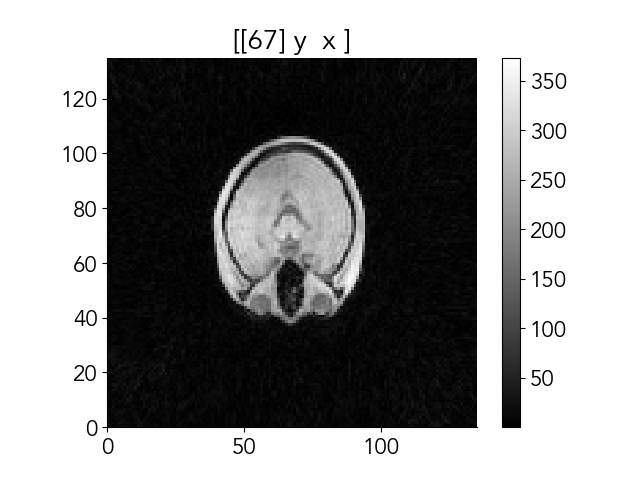

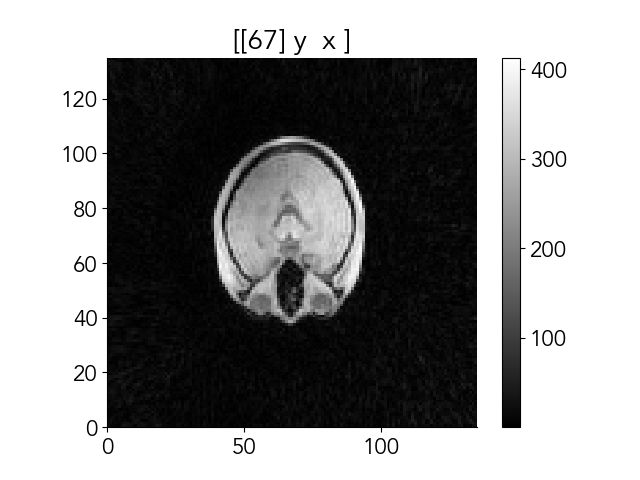

In [ ]:
pl.ImagePlot(S_old, colormap='gray')
pl.ImagePlot(no_motion_reference.S, colormap='gray')

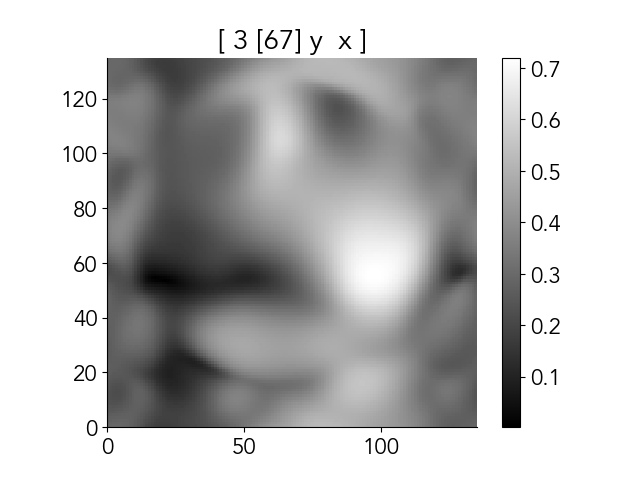

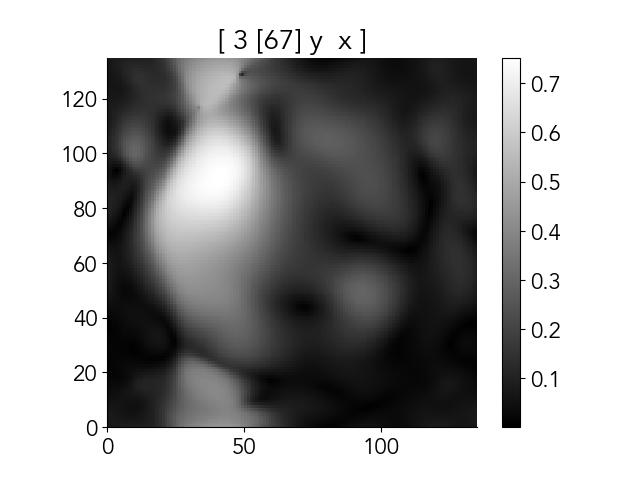

In [ ]:
pl.ImagePlot(csm_old, colormap='gray')
pl.ImagePlot(no_motion_reference.csm, colormap='gray')

#### Motion Frames

In [ ]:
from bpt_motus.preprocessing import MotionFrames

In [ ]:
import bpt_motus.preprocessing.process_xk as px
importlib.reload(px)

from bpt_motus.preprocessing.process_xk import MotionFrames

In [ ]:
# Process calibration k-space with motion
calib_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib"
motion_frames_c = MotionFrames(inp_dir=calib_inpdir, verbose=True)
motion_frames_c.run(force_reload=False)
# Process inference k-space with motion
inf_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/inf"
motion_frames_i = MotionFrames(inp_dir=
                               
                               inf_inpdir, verbose=True)
motion_frames_i.run(force_reload=False)

INFO: Radial acquisition split into frames found. Opening...
INFO: Radial acquisition split into frames found. Opening...


In [ ]:
print(f"Motion frames shape (calib): {motion_frames_c.xk_frames.shape}")
print(f"Inference frames shape (calib): {motion_frames_i.xk_frames.shape}")

Motion frames shape (calib): (6, 146, 500, 205)
Inference frames shape (calib): (6, 45, 500, 205)


In [ ]:
plot_bpt(np.tile(motion_frames_c.bpts_frames, (4,1,1)), shift = -20)

AttributeError: 'MotionFrames' object has no attribute 'bpts_frames'

## Lung UTE Scan Preparation

#### AIR Coil BPT Sweeps

In [40]:
from bpt_motus.io import bSSFPArchive
from bpt_motus.preprocessing import SplitXkBPT

In [41]:
import bpt_motus.io.bssfp_reader as bs
importlib.reload(bs)
from bpt_motus.io.bssfp_reader import bSSFPArchive

import bpt_motus.preprocessing.split_xk_bpt as sxb
importlib.reload(sxb)
from bpt_motus.preprocessing.split_xk_bpt import SplitXkBPT

In [36]:
# Path to bSSFP ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_030926/Series9_antcenter_rocker"

# Create the object
bssfp = bSSFPArchive(inpdir)

bssfp.get_metadata(force_reload=False)
bssfp.get_ksp(force_reload=False)

INFO: Loading cached metadata from /mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_030926/Series9_antcenter_rocker/metadata_dict.pkl
INFO: Loading cached k-space from /mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_030926/Series9_antcenter_rocker


In [37]:
print(f"xk_time shape: {bssfp.xk_time.shape}")
print(f"xk_recon shape: {bssfp.xk_recon.shape}")

xk_time shape: (16, 38400, 256)
xk_recon shape: (256, 150, 256, 16)


In [38]:
# Split into xk and BPT
split_xk_bpt = SplitXkBPT(inp_dir=inpdir, verbose=True)
split_xk_bpt.num_bpts = 1
split_xk_bpt.xk_raw_fname = "xk_time.npy"
split_xk_bpt.run(force_reload=False)

INFO: Cleaned k-space and raw BPT/PT signals found. Opening...


------------------------------
EXPERIMENT SUMMARY
Best coil:     6
Start time:    6.18 s
Step spacing:  2.00 s
Total steps:   116
Freq range:    1.20 → 3.50 GHz
------------------------------


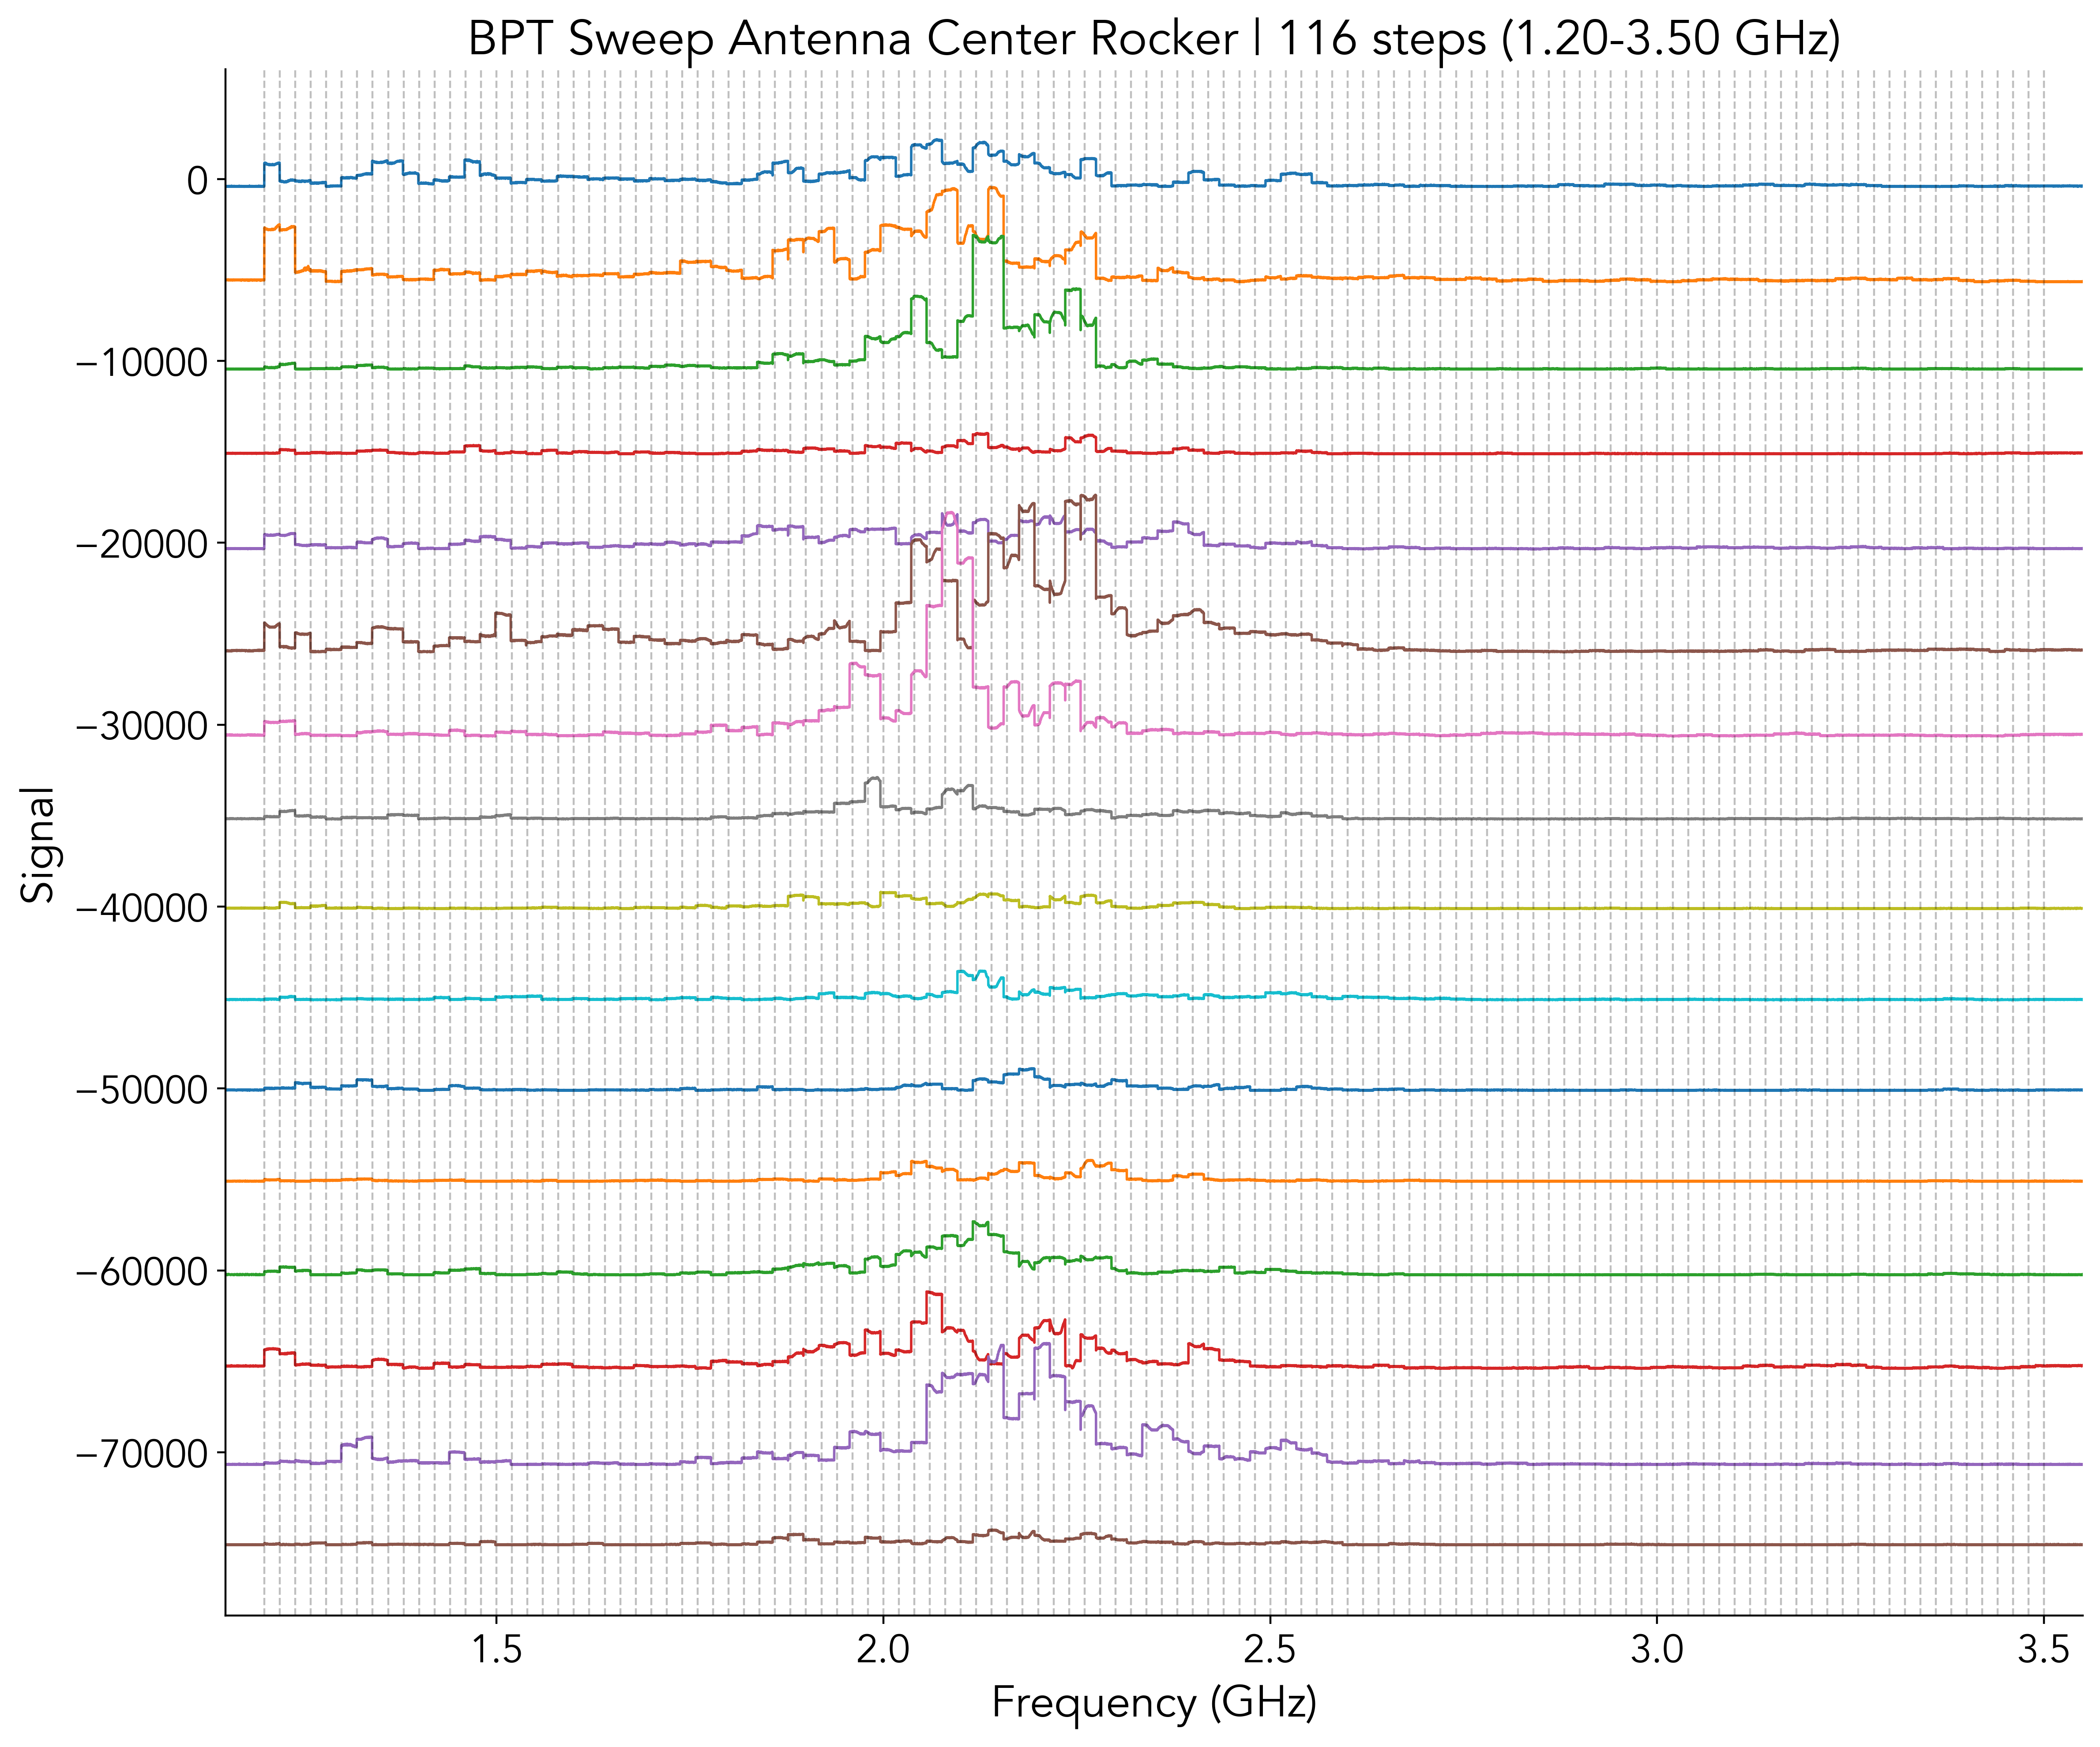

In [39]:
%matplotlib inline

def analyze_and_plot_steps(bpt, tr=1, shift=0,
                           figsize=(12,10),
                           dpi=300,
                           title="BPT",
                           step_time=2.0,
                           n_steps=116,
                           f_start=1.2,
                           f_stop=3.5,
                           f_step=0.02):

    npe, ncoils = bpt.shape
    t = np.arange(npe) * tr

    # -----------------------------
    # 1. Pick strongest coil
    # -----------------------------
    coil_ranges = np.max(bpt, axis=0) - np.min(bpt, axis=0)
    best_coil = np.argmax(coil_ranges)

    signal = bpt[:, best_coil]

    # -----------------------------
    # 2. Detect jumps via first difference
    # -----------------------------
    diff = np.diff(signal)

    baseline_len = int(10 / tr)
    baseline = diff[:baseline_len]

    threshold = np.mean(np.abs(baseline)) + 5*np.std(baseline)

    jump_indices = np.where(np.abs(diff) > threshold)[0]

    if len(jump_indices) == 0:
        print("No steps detected.")
        return

    # -----------------------------
    # 3. First jump = start time
    # -----------------------------
    start_idx = jump_indices[0] + 1
    start_time = start_idx * tr

    # -----------------------------
    # 4. Compute end time
    # -----------------------------
    end_time = start_time + (n_steps - 1) * step_time

    # -----------------------------
    # 5. Create frequency array
    # -----------------------------
    freqs = f_start + np.arange(n_steps) * f_step

    # Map time → frequency
    freq_axis = f_start + (t - start_time) / step_time * f_step

    # -----------------------------
    # Print summary
    # -----------------------------
    print("-" * 30)
    print("EXPERIMENT SUMMARY")
    print(f"Best coil:     {best_coil}")
    print(f"Start time:    {start_time:.2f} s")
    print(f"Step spacing:  {step_time:.2f} s")
    print(f"Total steps:   {n_steps}")
    print(f"Freq range:    {f_start:.2f} → {f_stop:.2f} GHz")
    print("-" * 30)

    # -----------------------------
    # Plot signals
    # -----------------------------
    plt.figure(figsize=figsize, dpi=dpi)

    offset_data = bpt - np.mean(bpt, axis=0) + np.arange(ncoils) * shift

    plt.plot(freq_axis, offset_data, lw=1.0)

    # -----------------------------
    # Draw frequency step lines
    # -----------------------------
    for f in freqs:
        plt.axvline(f, color='black', linestyle='--', alpha=0.25, lw=0.8)

    plt.title(f"{title} | {n_steps} steps ({f_start:.2f}-{f_stop:.2f} GHz)")
    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Signal")

    plt.xlim(f_start - 0.05, f_stop + 0.05)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

analyze_and_plot_steps(
    split_xk_bpt.bpts[0],
    tr=bssfp.metadata_dict['tr'],
    title="BPT Sweep Antenna Center Rocker",
    shift=-5e3,
    n_steps=116,
    f_start=1.2,
    f_stop=3.5,
    f_step=0.02,
    dpi=400
)

#### UTE Recon Testing

In [39]:
# add paths
from bpt_motus.io import RadialArchive
from bpt_motus.preprocessing import NoMotionReference
from bpt_motus.preprocessing import SplitXkBPT

from GERecon import Archive, Gradwarp

In [3]:
import bpt_motus.io.radial_reader as rr
importlib.reload(rr)
from bpt_motus.io.radial_reader import RadialArchive

import bpt_motus.preprocessing.process_xk as px
importlib.reload(px)
from bpt_motus.preprocessing.process_xk import NoMotionReference

import bpt_motus.preprocessing.split_xk_bpt as sxb
importlib.reload(sxb)
from bpt_motus.preprocessing.split_xk_bpt import SplitXkBPT

In [4]:
# Path to radial ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/lung_ute/volunteer_032026/Exam54363/Series6"
# # Create the object
# radial = RadialArchive(inpdir) 
# radial.get_ksp(force_reload=False)
# # Compress k-space
# split_xk_bpt_nm = SplitXkBPT(inp_dir=inpdir, verbose=True)
# split_xk_bpt_nm._get_raw_xk()
# split_xk_bpt_nm.xk_cleaned = split_xk_bpt_nm.xk_ordered
# split_xk_bpt_nm._compress_kspace()
# np.save(split_xk_bpt_nm.xk_fname, split_xk_bpt_nm.xk_cleaned)
# Recon image
no_motion_reference = NoMotionReference(inp_dir=inpdir, center_out=True, verbose=True)
no_motion_reference.run(force_reload=False)

INFO: Reference image and CSMs found. Opening...


In [5]:
radial.coords_time.shape

NameError: name 'radial' is not defined

In [6]:
%matplotlib inline
pl.ScatterPlot(radial.coords_time[0:10,:,:2], title="First 10 spoke coordinates")

NameError: name 'radial' is not defined

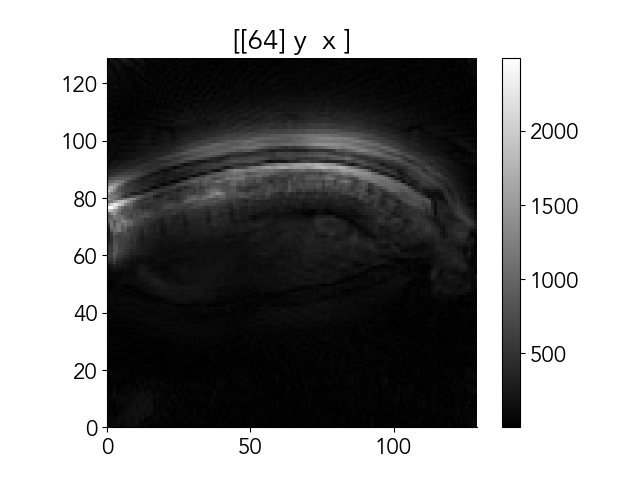

KeyError: 'buttons'

KeyError: 'buttons'

KeyError: 'buttons'

KeyError: 'buttons'

KeyError: 'buttons'

...

KeyError: 'buttons'

KeyError: 'buttons'

KeyError: 'buttons'

KeyError: 'buttons'

KeyError: 'buttons'

In [ ]:
%matplotlib widget
pl.ImagePlot(no_motion_reference.S.transpose(1,0,2), colormap='gray')

Debugging my UTE Recon

In [18]:
radial.xk_time.shape

(31, 10001, 525)

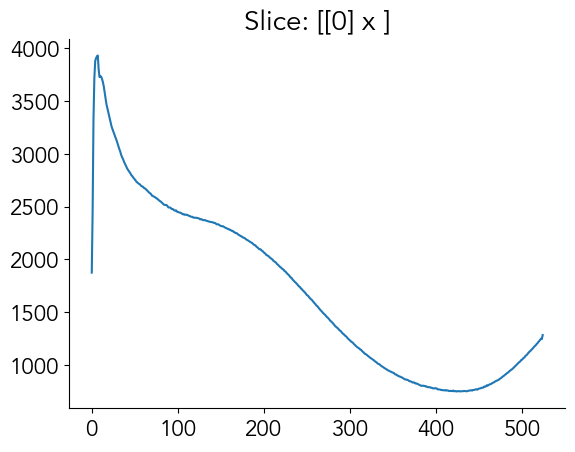

In [24]:
pl.LinePlot(split_xk_bpt_nm.xk_cleaned[2,:1,:])